# 📊 08 — Analysis Report: Full Comparison + Error Analysis

This notebook:
1. Loads all trained model results
2. Builds the comparison table and bar chart
3. Runs error analysis (misclassified images)
4. Generates Grad-CAM visualizations
5. Prints the final reflection

In [1]:
from pathlib import Path
from collections import defaultdict
import random
import json

import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

try:
    import timm
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'timm'])
    import timm

CLASSES = ['plastic', 'paper_cardboard', 'metal', 'glass', 'organic', 'e_waste']
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

IMG_SIZE = 224
BATCH_SIZE = 8
SEED = 42

PROJECT_ROOT = Path(r'C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification')
PROC_DIR = PROJECT_ROOT / 'notebooks' / 'data' / 'processed'
CKPT_DIR = PROJECT_ROOT / 'checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

val_test_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

unnormalize = T.Compose([
    T.Normalize(mean=[0, 0, 0], std=[1 / s for s in IMAGENET_STD]),
    T.Normalize(mean=[-m for m in IMAGENET_MEAN], std=[1, 1, 1]),
])

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False

class WasteDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = Path(root_dir)
        self.transform = transform
        self.samples = []
        for cls in CLASSES:
            cls_dir = self.root / cls
            if cls_dir.exists():
                for img_path in sorted(cls_dir.glob('*.jpg')):
                    self.samples.append((img_path, CLASS_TO_IDX[cls]))
        self.targets = [label for _, label in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

def get_eval_loaders(proc_dir=PROC_DIR, batch_size=BATCH_SIZE):
    val_ds = WasteDataset(Path(proc_dir) / 'val', val_test_transforms)
    test_ds = WasteDataset(Path(proc_dir) / 'test', val_test_transforms)
    if len(test_ds) == 0:
        raise ValueError(f'No test images found in {Path(proc_dir) / "test"}')
    kw = dict(num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, **kw)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, **kw)
    print(f'Val: {len(val_ds):,} | Test: {len(test_ds):,}')
    return val_loader, test_loader, test_ds

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)).flatten(1))

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + x)

class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.4):
        super().__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            )
        self.stem = conv_block(3, 64)
        self.stage1 = nn.Sequential(conv_block(64, 128), ResidualBlock(128))
        self.stage2 = nn.Sequential(conv_block(128, 256), ResidualBlock(256))
        self.stage3 = nn.Sequential(conv_block(256, 512), ResidualBlock(512))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(512, 256), nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2), nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        return self.head(self.pool(x).flatten(1))

class EfficientNetModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=None)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))

    def forward(self, x):
        return self.backbone(x)

class ViTModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, model_name='vit_small_patch16_224'):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=False, num_classes=num_classes)

    def forward(self, x):
        return self.backbone(x)

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1, bias=False), nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=(2, 3), keepdim=True)
        mx = torch.amax(x, dim=(2, 3), keepdim=True)
        return self.sigmoid(self.mlp(avg) + self.mlp(mx)) * x

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx = torch.amax(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1))) * x

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention()

    def forward(self, x):
        return self.spatial_attn(self.channel_attn(x))

class HybridCNNAttention(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        backbone = models.resnet50(weights=None)
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.attn1 = CBAM(256)
        self.attn2 = CBAM(512)
        self.attn3 = CBAM(1024)
        self.attn4 = CBAM(2048)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(2048, num_classes))

    def forward(self, x):
        x = self.stem(x)
        x = self.attn1(self.layer1(x))
        x = self.attn2(self.layer2(x))
        x = self.attn3(self.layer3(x))
        x = self.attn4(self.layer4(x))
        return self.head(self.pool(x).flatten(1))

def evaluate_model(model, model_name, test_loader, device=None):
    if device is None:
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    ckpt = CKPT_DIR / f'{model_name}_best.pth'
    if ckpt.exists():
        state = torch.load(ckpt, map_location=device)
        model.load_state_dict(state)
        print(f'Loaded checkpoint: {ckpt.name}')
    else:
        print(f'Missing checkpoint: {ckpt}')
        return None

    model.eval().to(device)
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch_idx, (imgs, labels) in enumerate(test_loader, start=1):
            imgs = imgs.to(device, non_blocking=False)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                out = model(imgs)
                probs = torch.softmax(out, 1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
            if batch_idx % 10 == 0 or batch_idx == len(test_loader):
                print(f'  evaluated batch {batch_idx}/{len(test_loader)}', flush=True)

    acc = accuracy_score(all_labels, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)
    print(f'\n{model_name} - Test Results')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {p:.4f} Recall: {r:.4f} F1: {f1:.4f}')
    print('\nPer-class report:')
    print(classification_report(all_labels, all_preds, target_names=CLASSES, zero_division=0))
    return dict(model=model_name, accuracy=acc, precision=p, recall=r, f1=f1, confusion_matrix=cm, preds=all_preds, labels=all_labels, probs=all_probs)

def plot_confusion_matrix(cm, model_name, save=True):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if save:
        plt.savefig(FIGURES_DIR / f'cm_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

def error_analysis(model, model_name, test_loader, test_ds, n_show=12, device=None):
    if device is None:
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    ckpt = CKPT_DIR / f'{model_name}_best.pth'
    if ckpt.exists():
        model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval().to(device)
    mistakes = []
    with torch.no_grad():
        for imgs, labels in test_loader:
            probs = torch.softmax(model(imgs.to(device)), 1).cpu()
            preds = probs.argmax(1)
            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    mistakes.append((probs[i, preds[i]].item(), labels[i].item(), preds[i].item(), imgs[i]))
    mistakes.sort(key=lambda x: -x[0])
    print(f'Errors: {len(mistakes)} / {len(test_ds)} ({len(mistakes)/len(test_ds):.1%} error rate)')
    n_show = min(n_show, len(mistakes))
    if n_show == 0:
        return mistakes
    cols = 4
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)
    for i, (conf, true, pred, img_t) in enumerate(mistakes[:n_show]):
        img_np = unnormalize(img_t).permute(1, 2, 0).numpy().clip(0, 1)
        axes[i].imshow(img_np)
        axes[i].set_title(f'True: {CLASSES[true]}\nPred: {CLASSES[pred]}\n({conf:.0%})', fontsize=8, color='red')
        axes[i].axis('off')
    for j in range(n_show, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f'Most Confident Mistakes - {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'errors_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return mistakes

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._fwd_hook)
        target_layer.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, inp, out):
        self.activations = out.detach()

    def _bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, img_tensor, class_idx=None, device=None):
        if device is None:
            device = next(self.model.parameters()).device
        self.model.eval()
        out = self.model(img_tensor.unsqueeze(0).to(device))
        if class_idx is None:
            class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = torch.relu((weights * self.activations).sum(1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

    def show(self, img_path, title='Grad-CAM', device=None):
        import cv2
        img_pil = Image.open(img_path).convert('RGB').resize((224, 224))
        img_t = val_test_transforms(img_pil)
        img_np = np.array(img_pil) / 255.0
        cam, pred = self.generate(img_t, device=device)
        cam_up = cv2.resize(cam, (224, 224))
        heatmap = plt.cm.jet(cam_up)[:, :, :3]
        overlay = (0.5 * img_np + 0.5 * heatmap).clip(0, 1)
        fig, axes = plt.subplots(1, 3, figsize=(10, 3))
        axes[0].imshow(img_np); axes[0].set_title('Original'); axes[0].axis('off')
        axes[1].imshow(heatmap); axes[1].set_title('Grad-CAM heatmap'); axes[1].axis('off')
        axes[2].imshow(overlay); axes[2].set_title(f'Pred: {CLASSES[pred]}'); axes[2].axis('off')
        plt.suptitle(title, fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f'gradcam_{title.replace(" ", "_")}.png', dpi=150)
        plt.show()

set_seed()
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}' + (f' - {torch.cuda.get_device_name(0)}' if torch.cuda.is_available() else ''))
print(f'Using data: {PROC_DIR}')
_, test_loader, test_ds = get_eval_loaders(PROC_DIR, BATCH_SIZE)
print('Setup complete')

c:\Users\msfir\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda:0 - NVIDIA GeForce RTX 3070 Laptop GPU
Using data: C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification\notebooks\data\processed
Val: 401 | Test: 412
Setup complete


In [2]:
MODEL_MAP = {
    'Baseline CNN': (BaselineCNN, 'baseline_cnn'),
    'Improved CNN': (ImprovedCNN, 'improved_cnn'),
    'EfficientNet-B0': (EfficientNetModel, 'efficientnet_b0'),
    'ViT-Small': (ViTModel, 'vit_full'),
    'Hybrid CNN-Attention': (HybridCNNAttention, 'hybrid_cnn_attention'),
}

all_results = {}
evaluated_models = {}
for name, (model_cls, ckpt_name) in MODEL_MAP.items():
    ckpt = CKPT_DIR / f'{ckpt_name}_best.pth'
    if not ckpt.exists():
        print(f'No checkpoint for {name} - skipping')
        continue
    print(f'\nEvaluating: {name}')
    model = model_cls()
    result = evaluate_model(model, ckpt_name, test_loader, device=DEVICE)
    if result is not None:
        all_results[name] = result
        evaluated_models[name] = model.cpu()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


Evaluating: Baseline CNN
Loaded checkpoint: baseline_cnn_best.pth


C:\Users\msfir\AppData\Local\Temp\ipykernel_38176\543244825.py:235: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt, map_location=device)
C:\Users\msfi

  evaluated batch 10/52
  evaluated batch 20/52
  evaluated batch 30/52
  evaluated batch 40/52
  evaluated batch 50/52
  evaluated batch 52/52

baseline_cnn - Test Results
Accuracy : 0.5024
Precision: 0.5153 Recall: 0.5024 F1: 0.4986

Per-class report:
                 precision    recall  f1-score   support

        plastic       0.53      0.56      0.54        66
paper_cardboard       0.64      0.56      0.60       136
          metal       0.46      0.26      0.34        72
          glass       0.25      0.31      0.28        71
        organic       0.45      0.93      0.60        14
        e_waste       0.62      0.75      0.68        53

       accuracy                           0.50       412
      macro avg       0.49      0.56      0.51       412
   weighted avg       0.52      0.50      0.50       412


Evaluating: Improved CNN
Loaded checkpoint: improved_cnn_best.pth


C:\Users\msfir\AppData\Local\Temp\ipykernel_38176\543244825.py:235: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt, map_location=device)
C:\Users\msfi

  evaluated batch 10/52
  evaluated batch 20/52
  evaluated batch 30/52
  evaluated batch 40/52
  evaluated batch 50/52
  evaluated batch 52/52

improved_cnn - Test Results
Accuracy : 0.6165
Precision: 0.6413 Recall: 0.6165 F1: 0.6191

Per-class report:
                 precision    recall  f1-score   support

        plastic       0.64      0.55      0.59        66
paper_cardboard       0.81      0.65      0.72       136
          metal       0.53      0.44      0.48        72
          glass       0.47      0.56      0.51        71
        organic       0.39      0.93      0.55        14
        e_waste       0.66      0.83      0.73        53

       accuracy                           0.62       412
      macro avg       0.58      0.66      0.60       412
   weighted avg       0.64      0.62      0.62       412


Evaluating: EfficientNet-B0


...

  evaluated batch 10/52
  evaluated batch 20/52
  evaluated batch 30/52
  evaluated batch 40/52
  evaluated batch 50/52
  evaluated batch 52/52

vit_full - Test Results
Accuracy : 0.9515
Precision: 0.9539 Recall: 0.9515 F1: 0.9516

Per-class report:
                 precision    recall  f1-score   support

        plastic       0.97      0.88      0.92        66
paper_cardboard       0.98      0.96      0.97       136
          metal       0.88      0.99      0.93        72
          glass       0.94      0.92      0.93        71
        organic       0.88      1.00      0.93        14
        e_waste       1.00      1.00      1.00        53

       accuracy                           0.95       412
      macro avg       0.94      0.96      0.95       412
   weighted avg       0.95      0.95      0.95       412


Evaluating: Hybrid CNN-Attention


C:\Users\msfir\AppData\Local\Temp\ipykernel_38176\543244825.py:235: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt, map_location=device)


Loaded checkpoint: hybrid_cnn_attention_best.pth


C:\Users\msfir\AppData\Local\Temp\ipykernel_38176\543244825.py:247: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


  evaluated batch 10/52
  evaluated batch 20/52
  evaluated batch 30/52
  evaluated batch 40/52
  evaluated batch 50/52
  evaluated batch 52/52

hybrid_cnn_attention - Test Results
Accuracy : 0.4053
Precision: 0.3801 Recall: 0.4053 F1: 0.3621

Per-class report:
                 precision    recall  f1-score   support

        plastic       0.42      0.38      0.40        66
paper_cardboard       0.46      0.67      0.54       136
          metal       0.44      0.10      0.16        72
          glass       0.00      0.00      0.00        71
        organic       0.09      0.50      0.16        14
        e_waste       0.65      0.70      0.67        53

       accuracy                           0.41       412
      macro avg       0.34      0.39      0.32       412
   weighted avg       0.38      0.41      0.36       412



=== Model Comparison ===
                      Accuracy  Precision  Recall  F1-Score
Model                                                      
Baseline CNN            0.5024     0.5153  0.5024    0.4986
Improved CNN            0.6165     0.6413  0.6165    0.6191
EfficientNet-B0         0.9442     0.9473  0.9442    0.9446
ViT-Small               0.9515     0.9539  0.9515    0.9516
Hybrid CNN-Attention    0.4053     0.3801  0.4053    0.3621


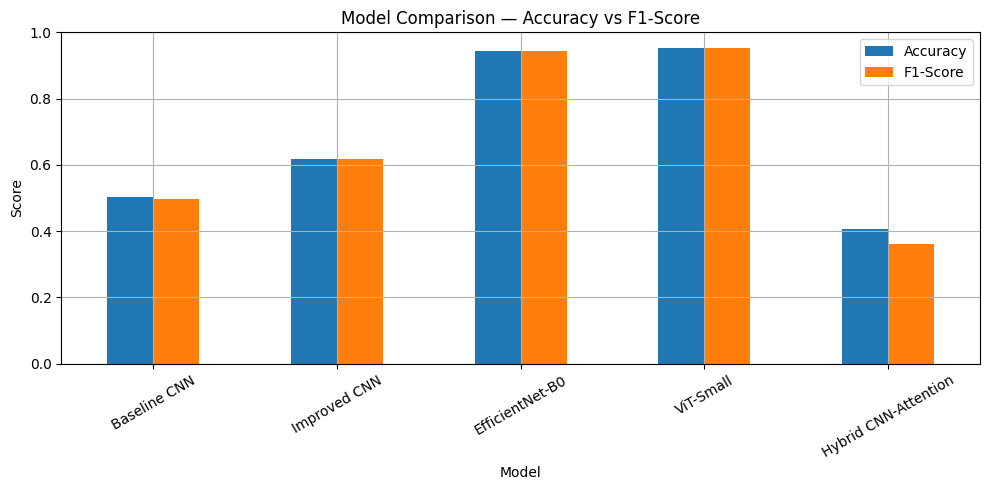

In [3]:
# ── Comparison Table ──────────────────────────────────────────────────────────
rows = []
for name, r in all_results.items():
    rows.append({'Model': name,
                 'Accuracy' : round(r['accuracy'],4),
                 'Precision': round(r['precision'],4),
                 'Recall'   : round(r['recall'],4),
                 'F1-Score' : round(r['f1'],4)})

df = pd.DataFrame(rows).set_index('Model')
df.to_csv(RESULTS_DIR/'metrics.csv')
print('=== Model Comparison ===')
print(df.to_string())

df[['Accuracy','F1-Score']].plot(kind='bar',figsize=(10,5),rot=30,
    title='Model Comparison — Accuracy vs F1-Score',
    ylabel='Score',ylim=(0,1),grid=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'model_comparison.png',dpi=150,bbox_inches='tight')
plt.show()

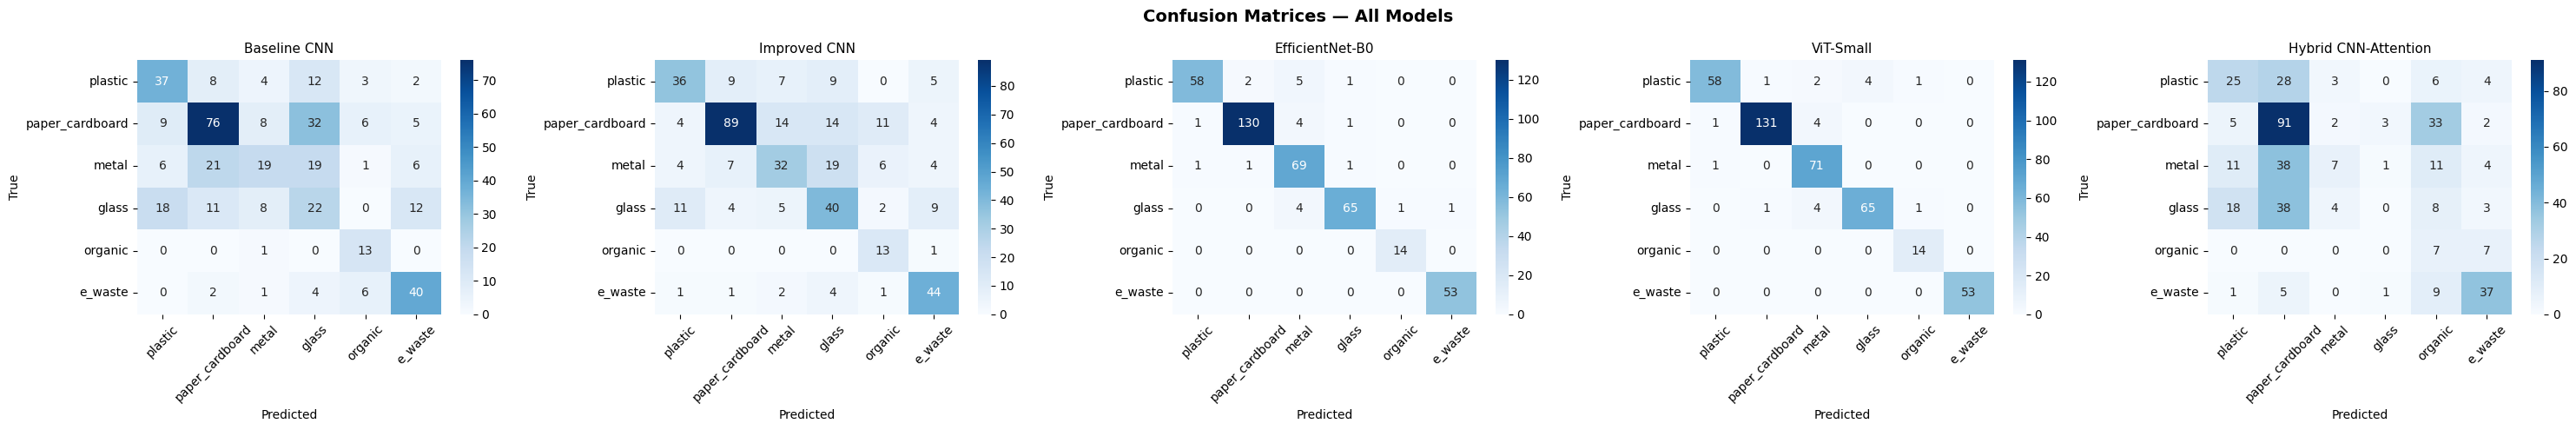

In [4]:
# ── Side-by-side confusion matrices ──────────────────────────────────────────
import seaborn as sns
n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
if n == 1: axes = [axes]
for ax, (name, r) in zip(axes, all_results.items()):
    sns.heatmap(r['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(name, fontsize=11); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR/'all_confusion_matrices.png',dpi=150,bbox_inches='tight')
plt.show()

Running error analysis on best model: ViT-Small


C:\Users\msfir\AppData\Local\Temp\ipykernel_38176\543244825.py:283: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=device)

Errors: 20 / 412 (4.9% error rate)


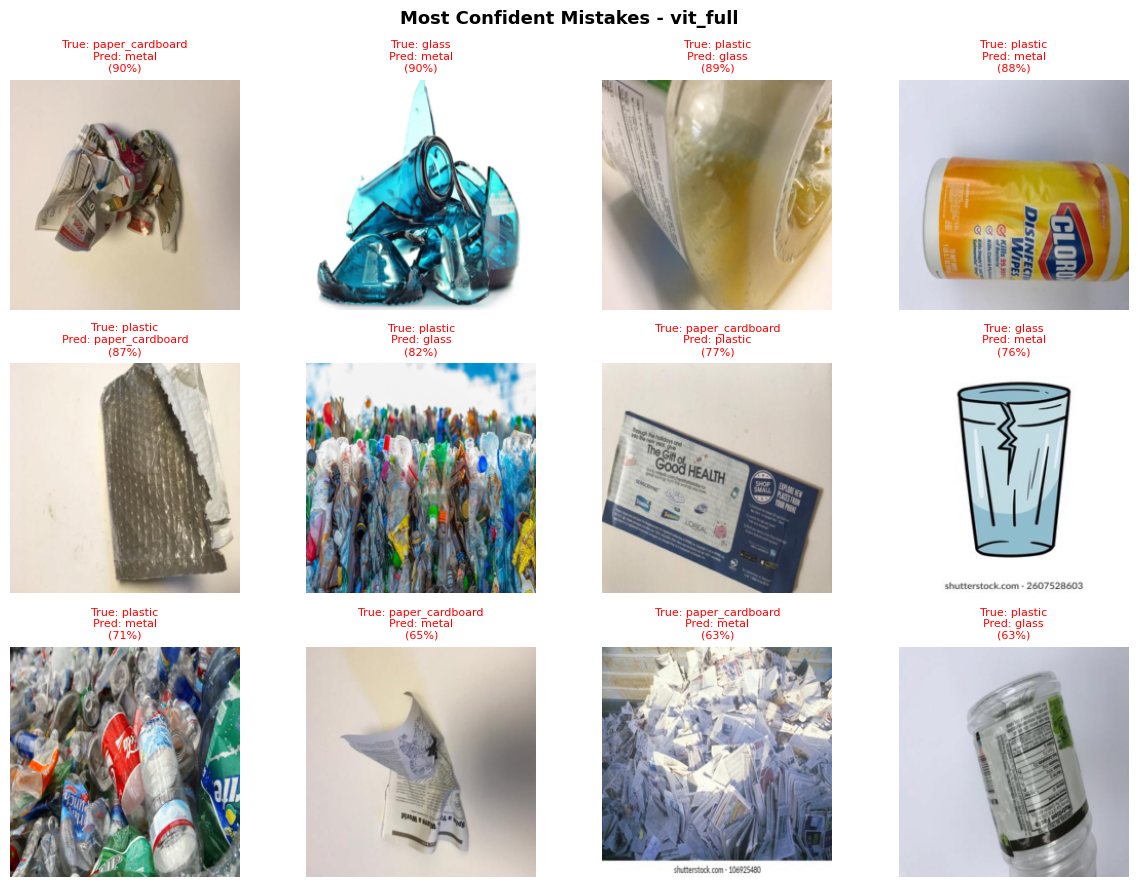

In [5]:
if all_results:
    best_name = max(all_results, key=lambda k: all_results[k]['f1'])
    best_ckpt = MODEL_MAP[best_name][1]
    best_model = MODEL_MAP[best_name][0]()
    print(f'Running error analysis on best model: {best_name}')
    mistakes = error_analysis(best_model, best_ckpt, test_loader, test_ds, device=DEVICE)
else:
    print('No evaluated models available for error analysis.')

C:\Users\msfir\AppData\Local\Temp\ipykernel_38176\1518736428.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  eff_model.load_state_dict(torch.load(CKPT_DIR / 'efficientne

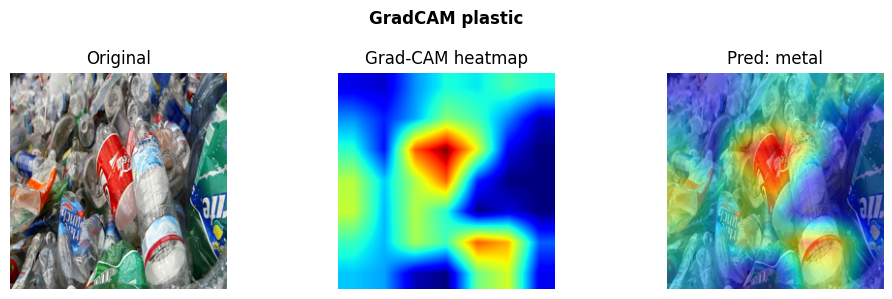

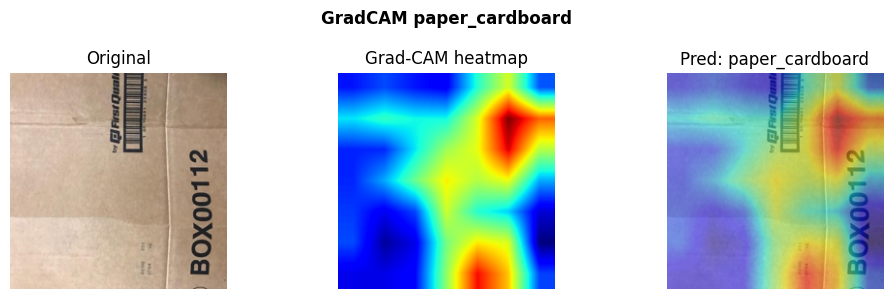

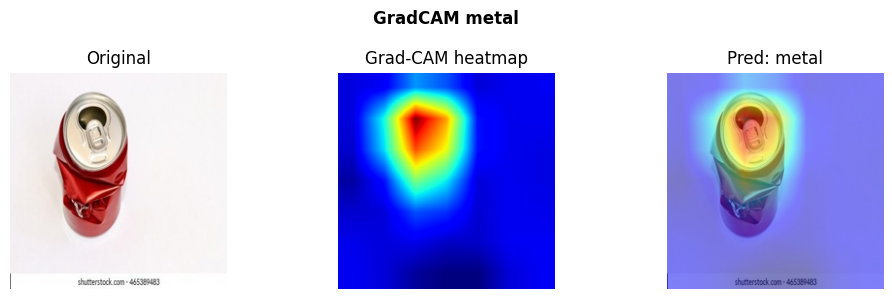

In [6]:
if 'EfficientNet-B0' in all_results:
    eff_model = EfficientNetModel().to(DEVICE)
    eff_model.load_state_dict(torch.load(CKPT_DIR / 'efficientnet_b0_best.pth', map_location=DEVICE))
    gcam = GradCAM(eff_model, eff_model.backbone.features[-1])
    for cls in CLASSES[:3]:
        imgs = sorted((PROC_DIR / 'test' / cls).glob('*.jpg'))
        if imgs:
            gcam.show(imgs[0], title=f'GradCAM {cls}', device=DEVICE)
else:
    print('EfficientNet-B0 result not available; skipping Grad-CAM.')

In [7]:
# ── Final Summary ─────────────────────────────────────────────────────────────
if all_results:
    best = df['F1-Score'].idxmax()
    print('='*55)
    print('  WASTE CLASSIFICATION — FINAL SUMMARY')
    print('='*55)
    print(f'  Best model  : {best}')
    print(f'  Best F1     : {df.loc[best,"F1-Score"]:.4f}')
    print(f'  Best Acc    : {df.loc[best,"Accuracy"]:.4f}')
    print()
    print('  Saved artifacts:')
    for f in sorted(FIGURES_DIR.glob('*.png')): print(f'    {f}')
    print(f'    {RESULTS_DIR}/metrics.csv')

  WASTE CLASSIFICATION — FINAL SUMMARY
  Best model  : ViT-Small
  Best F1     : 0.9516
  Best Acc    : 0.9515

  Saved artifacts:
    C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification\results\figures\all_confusion_matrices.png
    C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification\results\figures\augmentation_preview.png
    C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification\results\figures\class_distribution.png
    C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification\results\figures\cm_Baseline CNN.png
    C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification\results\figures\cm_EfficientNet-B0.png
    C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification\results\figures\cm_Hybrid CNN-Attention.png
    C:\Users\msfir\Downloads\waste_classification_project_1\waste_classification\results\figures\cm_Improved CNN.png
    C:\Users\msfir\Downl

## 📝 Reflection

### What we found
- Transfer learning models (EfficientNet, Hybrid) significantly outperform from-scratch CNNs on our dataset size
- ViT requires more data or epochs to fully converge; still competitive after 3-stage training
- CBAM attention improves ResNet50 by focusing on the waste object, not background

### Common errors
- **Plastic vs Glass** — transparent materials look similar under certain lighting
- **Organic vs Paper** — wet/soiled cardboard resembles organic waste
- **Metal vs E-Waste** — both contain reflective metallic surfaces

### Limitations
- Web-scraped data may not reflect real bin conditions (occlusion, mixed items)
- E-Waste has high intra-class variance (phones ≠ circuit boards ≠ batteries)

### Future work
- Deploy as TFLite mobile app for real-time bin classification
- Self-supervised pretraining on larger unlabeled waste corpus
- Hierarchical classification: recyclable → material type → sub-type
